# FinanceDatabase Project

In [3]:
import financedatabase as fd
from financetoolkit import Toolkit

equities = fd.Equities()
indices = fd.Indices()
ETF = fd.ETFs()

## Step 1: get the Revenue and Operating Income and EBIT numbers

In [73]:
# create callable 
company_list = equities.select(country="Japan",
                sector="Information Technology",
                only_primary_listing=True)

company_toolkit = company_list.to_toolkit(
    start_date = "2021-01-01",
    enforce_source = "YahooFinance"
)

income_statements = company_toolkit.get_income_statement()
# balance_sheets = company_toolkit.get_balance_sheet_statement()
# cashflow_statement = company_toolkit.get_cash_flow_statement()
# Revenue and operating income Operating Income	

#revenue_and_operating_income = income_statements.xs()

filtered = income_statements[
    income_statements.index.get_level_values(1).isin(
        ["Revenue", "Operating Income"]
    )
]
print(filtered)

The parameter api_key is not set. Therefore, using Yahoo Finance as the source which is limited to 5 years of fundamental data. Consider obtaining a key with the following link: https://www.jeroenbouma.com/fmp
You can get 15% off by using the above affiliate link to get access to 30+ years of (quarterly) data which also supports the project.


Obtaining income data: 100%|██████████| 79/79 [00:08<00:00,  9.65it/s]


2026-03-11 22:07:40 - financetoolkit - ERROR - The rate limit from Yahoo Finance has been reached or no data could be found from this source for the following tickers: CAJ, FBSE, FUAIY, ITTOY, MNBEY, OIDN, PCRFY, SFBTF, WRNT.
Consider obtaining an API key from FinancialModelingPrep to potentially avoid this issue. You can get 15% off by using the following affiliate link which also supports the project: https://www.jeroenbouma.com/fmp
2026-03-11 22:07:41 - financetoolkit - INFO - No income data found for the following tickers: CAJ, FBSE, FUAIY, ITTOY, MNBEY, OIDN, PCRFY, SFBTF, WRNT
                        2021           2022           2023           2024  \
ADTTF Revenue            NaN 416901000000.0 560191000000.0 486507000000.0   
      Operating Income   NaN 114734000000.0 167687000000.0  81628000000.0   
AITUF Revenue            0.0 105387000000.0 110919000000.0 109952000000.0   
      Operating Income   0.0  16500000000.0  11747000000.0   8984000000.0   
AITUY Revenue            

### Code to get profitability metrics

In [35]:
# create a quick to call toolkit item, enforce_source deviates from default using financial model prep to use yfinance as standard.
toolkit = Toolkit(["CRCL","XOM"], enforce_source="YahooFinance")

# collect the profitability ratios
profitability_ratios = toolkit.ratios.collect_profitability_ratios()

# display the profitability ratios for a specific ticker in this case CRCL.
profitability_ratios.loc["CRCL"]

Obtaining historical data: 100%|██████████| 3/3 [00:00<00:00,  9.84it/s]


,2021,2022,2023,2024,2025
Gross Margin,NaN,0.3235,0.2942,0.2359,0.0867
Operating Margin,NaN,0.0823,0.1616,0.0972,-0.0332
Net Profit Margin,NaN,-0.9958,0.1845,0.0929,-0.0253
Interest Coverage Ratio,NaN,28.6107,140.8436,112.1516,-11.8393
Income Before Tax Profit Margin,NaN,-0.9825,0.2199,0.1322,-0.0375
Effective Tax Rate,NaN,-0.0043,0.1486,0.2915,0.3244
Return on Assets,NaN,NaN,NaN,0.0043,-0.0011
Return on Equity,NaN,NaN,NaN,0.3421,-0.0356
Return on Invested Capital,NaN,NaN,NaN,0.3085,-0.0349
Return on Capital Employed,0.0,NaN,0.2032,0.1232,-0.03


# Code for messing around with the toolkit

Obtaining historical data: 100%|██████████| 3/3 [00:00<00:00,  9.77it/s]


Open                      High                       Low  \
           2222.T   8233.T Benchmark 2222.T   8233.T Benchmark 2222.T   
Date                                                                    
2010-01-04    NaN 452.9709   84.3077    NaN 464.4096    85.073    NaN   
2010-01-05    NaN 469.7477   84.9754    NaN 481.1864   85.2906    NaN   
2010-01-06    NaN 481.9489   85.1705    NaN 481.9489   85.5231    NaN   
2010-01-07    NaN 475.8483   85.1555    NaN 486.5244   85.7783    NaN   
2010-01-08    NaN 486.5242   85.4481    NaN 492.6248   85.9958    NaN   
...           ...      ...       ...    ...      ...       ...    ...   
2026-03-04 1821.0   1801.5    681.63 1860.5   1840.0    687.09 1813.5   
2026-03-05 1883.0   1821.5    682.08 1911.0   1829.0    685.53 1870.0   
2026-03-06 1870.0   1784.5    673.41 1929.5   1789.5    676.11 1865.5   
2026-03-09 1876.0   1718.0    666.39 1920.0   1761.5    679.92 1869.0   
2026-03-10 1939.0   1786.0    677.72 1939.0   1843.5    683.36 1907.5   

                               Close  ... Volatility Excess Return          \
             8233.T Benchmark 2222.T  ...  Benchmark        2222.T  8233.T   
Date                                  ...                                    
2010-01-04 451.4458   83.6625    NaN  ...     0.0108           NaN     NaN   
2010-01-05   467.46   84.6678    NaN  ...     0.0108           NaN -0.0145   
2010-01-06 481.9489    85.103    NaN  ...     0.0108           NaN -0.0187   
2010-01-07 475.8483   84.9155    NaN  ...     0.0108           NaN -0.0461   
2010-01-08 480.4236   85.2755    NaN  ...     0.0108           NaN  -0.011   
...             ...       ...    ...  ...        ...           ...     ...   
2026-03-04   1774.0    679.62 1851.5  ...     0.0108        -0.056  -0.051   
2026-03-05   1801.5    675.61 1876.0  ...     0.0108       -0.0283 -0.0256   
2026-03-06   1742.0    669.76 1929.5  ...     0.0108       -0.0128 -0.0643   
2026-03-09   1716.5    662.39 1917.5  ...     0.0108       -0.0476 -0.0619   
2026-03-10   1772.5    674.76 1912.5  ...     0.0108        -0.044  0.0142   

                     Excess Volatility                  Cumulative Return  \
           Benchmark            2222.T 8233.T Benchmark            2222.T   
Date                                                                        
2010-01-04       NaN               NaN 0.0213    0.0148               NaN   
2010-01-05    -0.035               NaN 0.0213    0.0148               NaN   
2010-01-06   -0.0374               NaN 0.0213    0.0148               NaN   
2010-01-07    -0.034               NaN 0.0213    0.0148               NaN   
2010-01-08   -0.0348               NaN 0.0213    0.0148               NaN   
...              ...               ...    ...       ...               ...   
2026-03-04   -0.0337            0.0253 0.0213    0.0148           46.1216   
2026-03-05   -0.0471            0.0253 0.0213    0.0148           46.7319   
2026-03-06   -0.0544            0.0253 0.0213    0.0148           48.0647   
2026-03-09   -0.0326            0.0253 0.0213    0.0148           47.7657   
2026-03-10    -0.043            0.0253 0.0213    0.0148           47.6412   

                             
           8233.T Benchmark  
Date                         
2010-01-04    1.0       1.0  
2010-01-05 1.0231    1.0026  
2010-01-06 1.0429    1.0034  
2010-01-07 1.0347    1.0076  
2010-01-08 1.0627    1.0109  
...           ...       ...  
2026-03-04 3.8864    8.0577  
2026-03-05 3.9481    8.0128  
2026-03-06 3.8572    7.9077  
2026-03-09 3.7782     7.977  
2026-03-10 3.9881    7.9642  

[4208 rows x 36 columns]

Open                          High                           Low  \
        2222.T    8233.T Benchmark    2222.T    8233.T Benchmark    2222.T   
Date                                                                         
2010   45.8519  544.7855   96.0301   46.0528  546.0758   96.2902   45.7971   
2011   45.6775   434.459   98.4275    45.734  438.3943   98.6696   45.6211   
2012   57.8027  495.9406  111.4998   57.8893  496.9413   113.815   57.6872   
2013  107.7377  843.1266  149.9227  109.1543   847.787  150.4277  105.4062   
2014  143.2808  798.9168  172.7155  143.7836  801.6482  172.8815  142.2551   
2015  305.6451  896.2818  173.8556  305.7983  905.8035  174.4997  300.1297   
2016  507.2432  809.9983  194.5574  521.8895    815.88   194.644  507.2432   
2017  1185.875 1011.7987  236.9963 1189.6159 1017.7505   237.014 1169.0408   
2018  799.1829  603.9925  224.4378  799.1829  603.9925  225.0043  799.1829   
2019 1541.6706  531.2293   293.722 1546.8966  540.8661  295.1881 1523.6171   
2020 1020.0884  398.0938  347.0478 1029.6667  399.8921  349.7362 1004.7632   
2021 1077.1537  495.2921  449.9171 1079.7183  497.4363  451.0711 1059.2011   
2022 1491.1726  843.0376  365.8961 1510.4883  867.8465  367.7609 1473.7884   
2023 2091.3854  915.8003  464.9948 2110.8492  919.6023  465.5218 2082.6267   
2024 2149.0097 1241.4601  583.0629 2167.0313 1243.1554  583.7845 2102.2277   
2025 1836.1667 1627.7631    687.14    1853.5 1642.6421    687.36 1819.3333   
2026    1939.0    1786.0    677.72    1939.0    1843.5    683.36    1907.5   

                             Close  ... Volatility Excess Return          \
        8233.T Benchmark    2222.T  ...  Benchmark        2222.T  8233.T   
Date                                ...                                    
2010  538.3337   95.8771   45.9798  ...      0.177           0.0     0.0   
2011  432.8848   98.0213   45.6775  ...     0.2279       -0.0253 -0.2082   
2012   484.933   111.404   57.7738  ...     0.1254        0.2472  0.1023   
2013  838.8714  149.8087  106.1292  ...     0.1092        0.8067  0.6879   
2014  789.3572  170.5564  142.3557  ...     0.1108        0.3196 -0.0824   
2015  875.1684  172.7877  301.5086  ...     0.1524        1.0953  0.0933   
2016  807.4775  192.8259  518.1816  ...     0.1303        0.6941 -0.1085   
2017 1004.9967  235.3283 1174.6522  ...     0.0666        1.2429  0.2209   
2018  603.9925  222.5582  799.1829  ...     0.1685       -0.3465 -0.4279   
2019  530.4627  293.3737 1526.4677  ...     0.1235        0.8908 -0.1297   
2020  388.6529  346.5344 1018.1728  ...     0.3295       -0.3422 -0.2804   
2021  490.2381  448.9996 1063.0481  ...     0.1292         0.029  0.2451   
2022  830.8671  363.7717 1493.1041  ...     0.2394        0.3657  0.7095   
2023  908.6716  461.8818 2103.0637  ...     0.1295        0.3698  0.0198   
2024 1215.3037  577.6366 2121.4836  ...      0.124       -0.0369  0.2891   
2025 1619.9929    681.71 1825.3333  ...     0.1921       -0.1812  0.2972   
2026    1772.5    674.76    1912.5  ...     0.1182        0.0064   0.088   

               Excess Volatility                  Cumulative Return         \
     Benchmark            2222.T 8233.T Benchmark            2222.T 8233.T   
Date                                                                         
2010       0.0            0.2681 0.2826    0.1919               1.0    1.0   
2011    0.0002            0.2777 0.3529    0.2444            0.9934 0.8105   
2012    0.1423            0.1279  0.211    0.1281            1.2565 0.9076   
2013    0.2928            0.2725 0.3762    0.1283            2.3082 1.5595   
2014    0.1129            0.2574 0.2429    0.1154             3.096 1.4649   
2015   -0.0104            0.3728  0.284    0.1545            6.5574 1.6348   
2016    0.0955            0.4835 0.3428    0.1384           11.2698 1.4975   
2017    0.1931            0.2869 0.2029    0.0676           25.5471 1.8642   
2018   -0.0726            0.4088 0.2866    0.1717           17.3812 1.

<Axes: title={'center': 'Cumulative Returns of Apple, Microsoft, Google and Amazon'}, xlabel='Date', ylabel='Cumulative Return'>

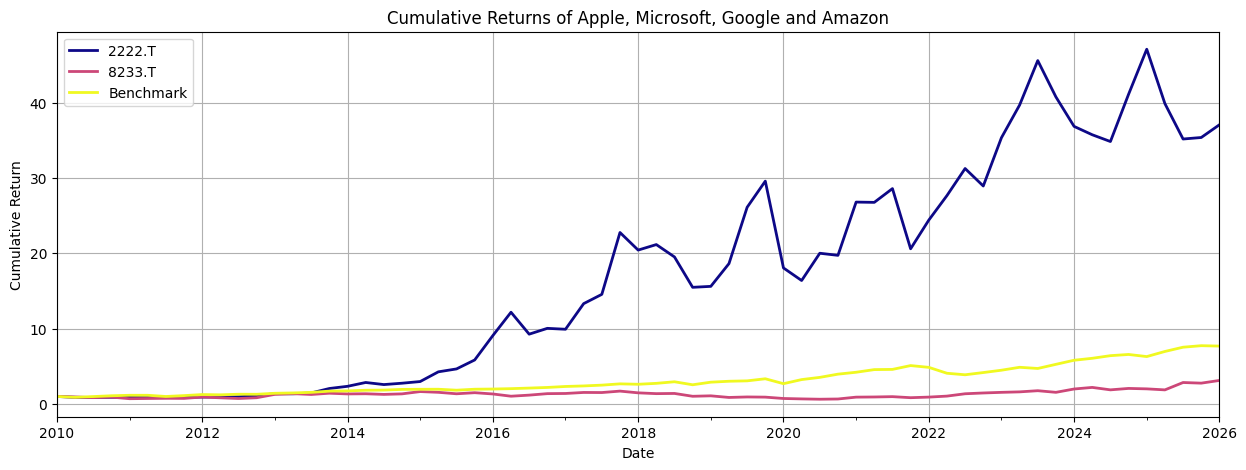

In [26]:
companies = Toolkit(
    ["2222.t","8233.T"],
    start_date="2010-01-01"
)

# obtain daily historical data from each company
display(companies.get_historical_data())

# Obtain Yearly historical data from each company
display(companies.get_historical_data(period="yearly"))

# Plot the Cumulative Returns
companies.get_historical_data(period="quarterly")["Cumulative Return"].plot(
    figsize=(15, 5),
    title="Cumulative Returns of Apple, Microsoft, Google and Amazon",
    grid=True,
    linestyle="-",
    linewidth=2,
    colormap="plasma",
    xlabel="Date",
    ylabel="Cumulative Return",
)

### Below code are some example queries using the fiancedatabase package

In [8]:
# see all equities that are available
equities.select()
# All possible options per column.
fd.show_options("equities")
# filter per counry to see the options for this specific country
equities.show_options(country="Netherlands",
                      sector="Financials",
                      selection="industry")
# example of how to show just the dutch stocks available
equities.select(country="Netherlands",
                sector = "Financials")
# further you can filter on primary listings
equities.select(country="United States",
                sector= "Financials",
                only_primary_listing=True)
# select multiple criteria 
equities.select(
    country=["United States", "Netherlands"],
    industry=["Chemicals", "Insurance"],
    market=["Euronext Amsterdam", "Nordic Growth Market", 
            "OTC Bulletin Board", "New York Stock Exchange", 
            "NASDAQ Global Select", "NYSE MKT", "NASDAQ Capital Market"]
)

# can also use the search command
equities.search(
    summary = ["Robotics", "Education"],
    industry_group = "Equipment",
    market = "Frankfurt",
    index = ".F"
)

,name,summary,currency,sector,industry_group,industry,exchange,market,country,state,city,zipcode,website,market_cap,isin,cusip,figi,composite_figi,shareclass_figi
symbol,,,,,,,,,,,,,,,,,,,
109.F,"Castlight Health, Inc.","Castlight Health, Inc. provides health navigat...",EUR,Health Care,Health Care Equipment & Services,Health Care Providers & Services,FRA,Frankfurt Stock Exchange,United States,CA,San Francisco,94105,http://www.castlighthealth.com,Small Cap,NaN,NaN,NaN,NaN,NaN
1KT.F,"Keysight Technologies, Inc.","Keysight Technologies, Inc. provides electroni...",EUR,Information Technology,Technology Hardware & Equipment,"Electronic Equipment, Instruments & Components",FRA,Frankfurt Stock Exchange,United States,CA,Santa Rosa,95403-1738,http://www.keysight.com,Large Cap,US49338L1035,49338L103,BBG007DJZFD2,BBG007DJZFC3,BBG0059FN820
1N1.F,Nanalysis Scientific Corp.,"Nanalysis Scientific Corp., develops, manufact...",EUR,Information Technology,Technology Hardware & Equipment,"Electronic Equipment, Instruments & Components",FRA,Frankfurt Stock Exchange,Canada,AB,Calgary,T2E 7C3,http://www.nanalysis.com,Nano Cap,NaN,NaN,NaN,NaN,NaN
1YO.F,Yangtze Optical Fibre And Cable Joint Stock Li...,Yangtze Optical Fibre And Cable Joint Stock Li...,EUR,Information Technology,Technology Hardware & Equipment,Communications Equipment,FRA,Frankfurt Stock Exchange,China,NaN,Wuhan,430073,http://www.yofc.com,Small Cap,NaN,NaN,NaN,NaN,NaN
1ZU.F,"The Pennant Group, Inc.","The Pennant Group, Inc. provides healthcare se...",EUR,Health Care,Health Care Equipment & Services,Health Care Equipment & Supplies,FRA,Frankfurt Stock Exchange,United States,ID,Eagle,83616,http://pennantgroup.com,Small Cap,US70805E1091,7.08E+113,BBG00QJ35K78,BBG00QJ35K69,BBG00P33SZ15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
V00.F,"Vocera Communications, Inc.","Vocera Communications, Inc. provides secure, i...",EUR,Information Technology,Technology Hardware & Equipment,Communications Equipment,FRA,Frankfurt Stock Exchange,United States,CA,San Jose,95126,http://www.vocera.com,Small Cap,NaN,NaN,NaN,NaN,NaN
VNI.F,"Avnet, Inc.","Avnet, Inc., a technology solutions company, m...",EUR,Information Technology,Technology Hardware & Equipment,"Electronic Equipment, Instruments & Components",FRA,Frankfurt Stock Exchange,United States,AZ,Phoenix,85034,http://www.avnet.com,Mid Cap,US0538071038,53807103,BBG000G99V31,BBG000G99TC6,BBG001S5NZJ2
WB6B.F,Tinkerine Studios Ltd.,"Tinkerine Studios Ltd. designs, manufactures, ...",EUR,Information Technology,Technology Hardware & Equipment,"Technology Hardware, Storage & Peripherals",FRA,Frankfurt Stock Exchange,Canada,BC,Delta,V4G 0A4,http://www.tinkerine.com,Nano Cap,NaN,NaN,NaN,NaN,NaN


# Screener logic below


In [ ]:
### Company should be growing from increased year over year growth in revenue and operating income / EBIT. 
### if business is becoming more efficient, ROC in profits < ROC in revenue.

### Retrieve profit margins, should be at least 10% for EBIT margin, lets take the average over all the years 
### as we will be only looking at the last 4 years as we are using Yfinance, preferably an increasing trend in PFM
### compare normalized EBIT and EBIT to see if there are systematic discrepancies.
 
### next look at ROCE > 15%, if Roce very high this can be a warning that there are hidden liabilities, 
### such as contractual leases or implicit guarantees not noted as liabilities of the firm
### Perhaps build lease adjust ROCE metric 
### Lease adjusted ROCE = (EBIT + PP * Interest rate) / (Total assets – current liabilities + short term borrowing + PP)

#### Next is Dupont Analysis, ROCE = Profit Margin * capital Turnover SKIP FOR NOW Model requires API KEY, perhaps able with custom ratios

#### compare FCFF to FCF not for now, implement later.

### Quality of converting profit to cash operating cash conversion ratio


##### Company should be growing from increased year over year growth in revenue and operating income / EBIT. 
##### if business is becoming more efficient, ROC in profits < ROC in revenue.

##### Retrieve profit margins, should be at least 10% for EBIT margin, lets take the average over all the years 
##### as we will be only looking at the last 4 years as we are using Yfinance, preferably an increasing trend in PFM
##### compare normalized EBIT and EBIT to see if there are systematic discrepancies.
 
### next look at ROCE > 15%, if Roce very high this can be a warning that there are hidden liabilities, 
### such as contractual leases or implicit guarantees not noted as liabilities of the firm
### Perhaps build lease adjust ROCE metric 
### Lease adjusted ROCE = (EBIT + PP * Interest rate) / (Total assets – current liabilities + short term borrowing + PP)

#### Next is Dupont Analysis, ROCE = Profit Margin * capital Turnover SKIP FOR NOW Model requires API KEY, perhaps able with custom ratios

#### compare FCFF to FCF not for now, implement later.

### Quality of converting profit to cash operating cash conversion ratio